# Sales Forecasting & Demand Intelligence System
### Task 1 — Data Loading, Merging & Deep Exploration

Dataset: Sample Superstore Sales (Kaggle) — daily order-level sales, 2015-2018, US retail.
Secondary dataset: Video Game Sales (Kaggle, gregorut/videogamesales) — used only for the multi-source merge exercise below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1.1 Load and inspect the Superstore data

In [2]:
df = pd.read_csv('train.csv', encoding='latin1')
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

Order Date and Ship Date came in as `dd/mm/yyyy`, not the US `mm/dd/yyyy` format you'd normally assume for a US retail dataset — worth double-checking before parsing, or every date past the 12th of the month silently breaks.

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
print(df['Order Date'].min(), '->', df['Order Date'].max())

2015-01-03 00:00:00 -> 2018-12-30 00:00:00


## 1.2 Missing values, duplicates, data type issues

In [5]:
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Only Postal Code has nulls (11 rows), and it's not used anywhere in the forecasting pipeline, so it's safe to leave as-is rather than dropping rows or imputing.

In [6]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate Row IDs:', df['Row ID'].duplicated().sum())

Duplicate rows: 0
Duplicate Row IDs: 0


No duplicate rows and no duplicate Row IDs — the dataset is clean at the row level.

## 1.3 Time feature extraction

In [7]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}
df['Season'] = df['Month'].map(season_map)

df['ShipDelayDays'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date', 'Year', 'Month', 'Week', 'DayOfWeek', 'Quarter', 'Season', 'ShipDelayDays']].head()

,Order Date,Year,Month,Week,DayOfWeek,Quarter,Season,ShipDelayDays
0,2017-11-08,2017,11,45,Wednesday,4,Fall,3
1,2017-11-08,2017,11,45,Wednesday,4,Fall,3
2,2017-06-12,2017,6,24,Monday,2,Summer,4
3,2016-10-11,2016,10,41,Tuesday,4,Fall,7
4,2016-10-11,2016,10,41,Tuesday,4,Fall,7


## 1.4 Weekly and monthly aggregation

In [8]:
daily_sales = df.groupby('Order Date')['Sales'].sum()

weekly_sales = daily_sales.resample('W').sum()
monthly_sales = daily_sales.resample('MS').sum()

print('Weekly points:', len(weekly_sales), '| Monthly points:', len(monthly_sales))
weekly_sales.head()

Weekly points: 209 | Monthly points: 48


Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

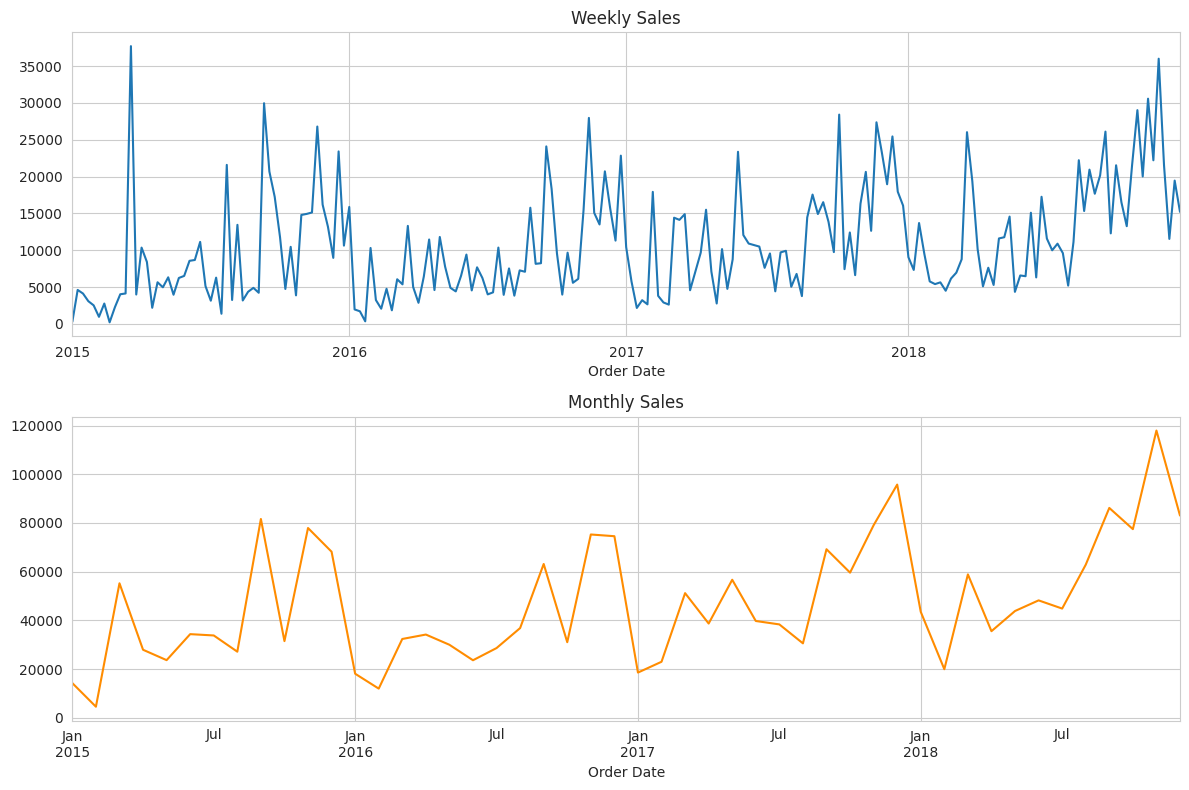

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
weekly_sales.plot(ax=axes[0], title='Weekly Sales')
monthly_sales.plot(ax=axes[1], title='Monthly Sales', color='darkorange')
plt.tight_layout()
plt.savefig('charts/weekly_monthly_sales.png', dpi=150)
plt.show()

## 1.5 EDA questions

**Q1 — Which product category generates the highest total revenue?**

In [10]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_revenue

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

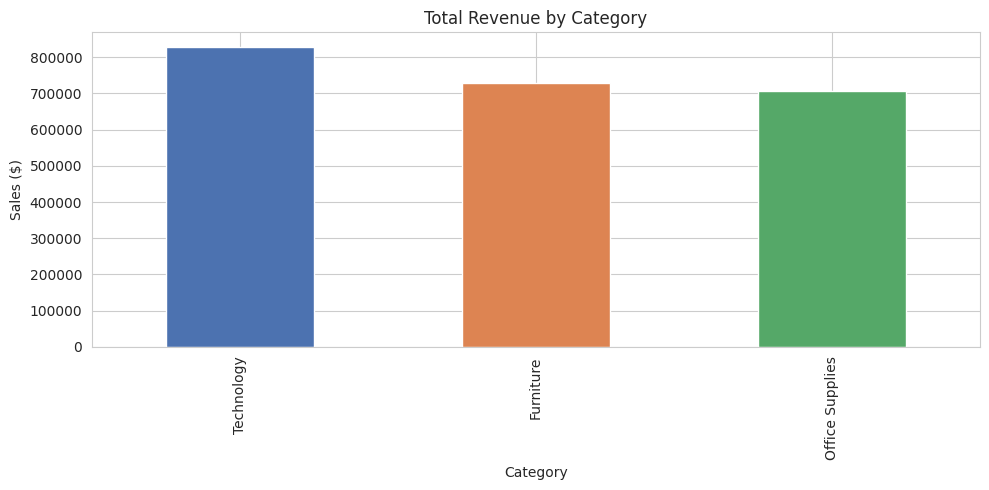

In [11]:
category_revenue.plot(kind='bar', color=['#4c72b0', '#dd8452', '#55a868'], title='Total Revenue by Category')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/revenue_by_category.png', dpi=150)
plt.show()

**Technology generates the highest total revenue** (~$827K), narrowly ahead of Furniture (~$729K) and Office Supplies (~$705K). Interesting wrinkle: Office Supplies has by far the most orders (5,909 vs. 1,813 for Technology) but the lowest revenue — it's a high-frequency, low-ticket category, while Technology is the opposite: fewer orders, higher value each.

**Q2 — Which region has the most consistent sales growth over 4 years?**

In [12]:
region_year = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
region_yoy = region_year.pct_change(axis=1) * 100
region_year

Year,2015,2016,2017,2018
Region,,,,
Central,102920.5206,102425.1724,145673.8800,141627.3402
East,127652.8190,153225.1830,178511.5380,210129.1860
South,103374.9055,70076.0825,93535.9035,122164.5675
West,145907.9630,133709.5675,182471.2285,248130.9255


In [13]:
region_yoy

Year,2015,2016,2017,2018
Region,,,,
Central,NaN,-0.481292,42.224686,-2.777807
East,NaN,20.032745,16.502741,17.711823
South,NaN,-32.211708,33.477643,30.607139
West,NaN,-8.360336,36.468341,35.983589


In [14]:
region_yoy.std(axis=1).sort_values().rename('YoY growth std dev (lower = more consistent)')

Region
East        1.793948
Central    25.345279
West       25.743054
South      37.124876
Name: YoY growth std dev (lower = more consistent), dtype: float64

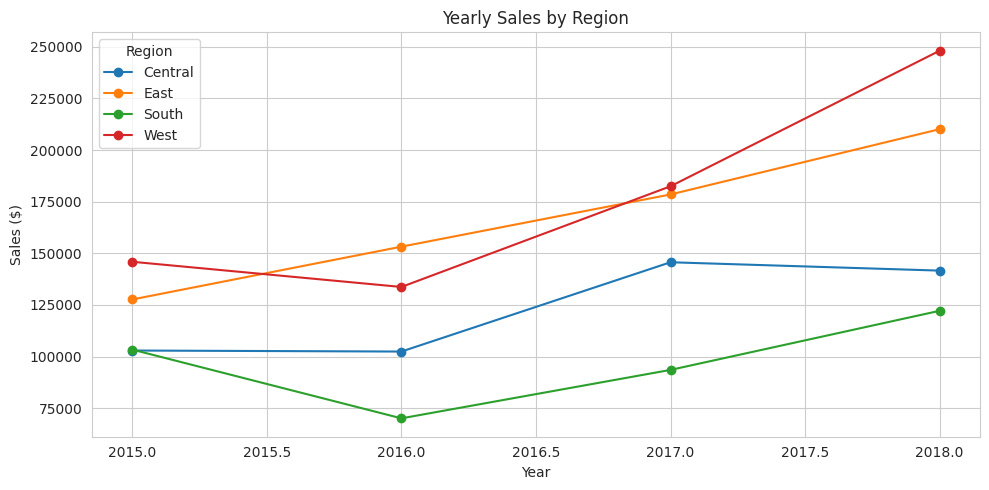

In [15]:
region_year.T.plot(marker='o', title='Yearly Sales by Region')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/sales_by_region_yearly.png', dpi=150)
plt.show()

**East is the most consistent grower** — +20.0%, +16.5%, +17.7% year over year, a standard deviation of under 2 percentage points. West has the highest absolute revenue and the strongest single-year growth (+36% in 2018), but South is genuinely volatile: -32%, then +33%, then +31%. That volatility is worth flagging again later in the anomaly detection task.

**Q3 — What is the average time between Order Date and Ship Date, and does it vary by region?**

In [16]:
print('Overall average ship delay:', round(df['ShipDelayDays'].mean(), 2), 'days')
df.groupby('Region')['ShipDelayDays'].mean().sort_values()

Overall average ship delay: 3.96 days


Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: ShipDelayDays, dtype: float64

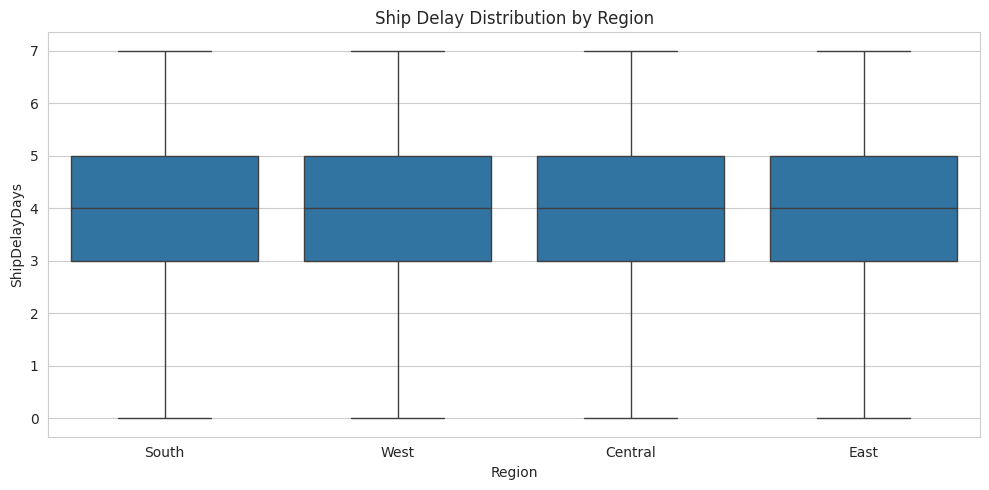

In [17]:
sns.boxplot(data=df, x='Region', y='ShipDelayDays')
plt.title('Ship Delay Distribution by Region')
plt.tight_layout()
plt.savefig('charts/ship_delay_by_region.png', dpi=150)
plt.show()

Average ship delay is **3.96 days overall**, and it barely moves by region (3.91 to 4.07 days). Shipping logistics are not a meaningful regional differentiator in this dataset — worth noting so we don't over-read noise into it later.

**Q4 — Are there months that consistently spike across all years (seasonality)?**

In [18]:
monthly_by_year = df.groupby(['Year', 'Month'])['Sales'].sum().unstack(0)
monthly_by_year

Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


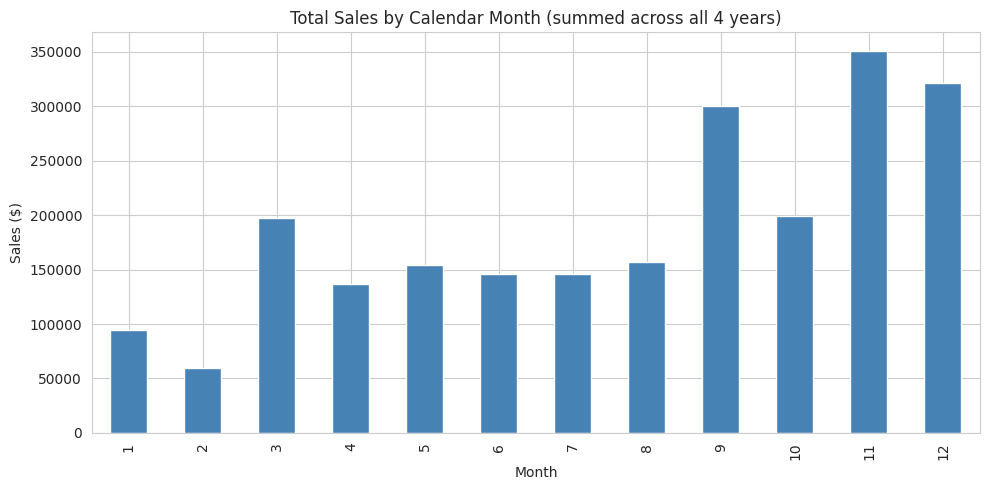

In [19]:
monthly_totals = df.groupby('Month')['Sales'].sum()
monthly_totals.plot(kind='bar', color='steelblue', title='Total Sales by Calendar Month (summed across all 4 years)')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/monthly_seasonality.png', dpi=150)
plt.show()

**Yes — November and September spike every single year**, and January/February are consistently the weakest months, every year without exception. That's a strong, reliable seasonal signal (almost certainly holiday and back-to-school retail behavior) and it's exactly what we'll want SARIMA and Prophet to capture in Task 3.

## 1.6 Multi-source practice merge — Video Game Sales dataset

The brief flags this as practice for merging and multi-source analysis. It isn't a natural fit with retail sales data (different domain, different granularity — VGChartz platform sales vs. Superstore order-level sales), so this is scoped as exactly what it's labeled: a merge/join exercise, not something feeding into the forecasting models in later tasks.

In [20]:
vg = pd.read_csv('vgsales.csv')
print(vg.shape)
vg.head()

(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [21]:
vg.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

271 rows are missing `Year` and 58 are missing `Publisher`. More importantly — checking the actual year range shows this dataset's real coverage stops well short of the Superstore window:

In [22]:
vg_yearly = vg.dropna(subset=['Year']).groupby('Year')['Global_Sales'].sum()
vg_yearly.loc[2013:2020]

Year
2013.0    368.11
2014.0    337.05
2015.0    264.44
2016.0     70.93
2017.0      0.05
2020.0      0.29
Name: Global_Sales, dtype: float64

Sales data effectively **stops after 2016** — 2017 and beyond have only 4 stray rows total (games with no meaningful reported sales), and there isn't a single 2018 row. This dataset was compiled with a scrape cutoff around 2016-2017, so a Year-based join against 2015-2018 Superstore data only has two usable overlapping years (2015, 2016), and even those are thin at the tail. That's a real data-quality constraint, not a bug in the merge — worth stating plainly rather than forcing a 4-year comparison the source data can't support.

In [23]:
superstore_yearly = df.groupby('Year')['Sales'].sum()

comparison = pd.DataFrame({
    'Superstore_Sales_USD': superstore_yearly,
    'VideoGame_Global_Sales_Millions': vg_yearly
}).loc[2015:2016]
comparison

,Superstore_Sales_USD,VideoGame_Global_Sales_Millions
Year,,
2015.0,479856.2081,264.44
2016.0,459436.0054,70.93


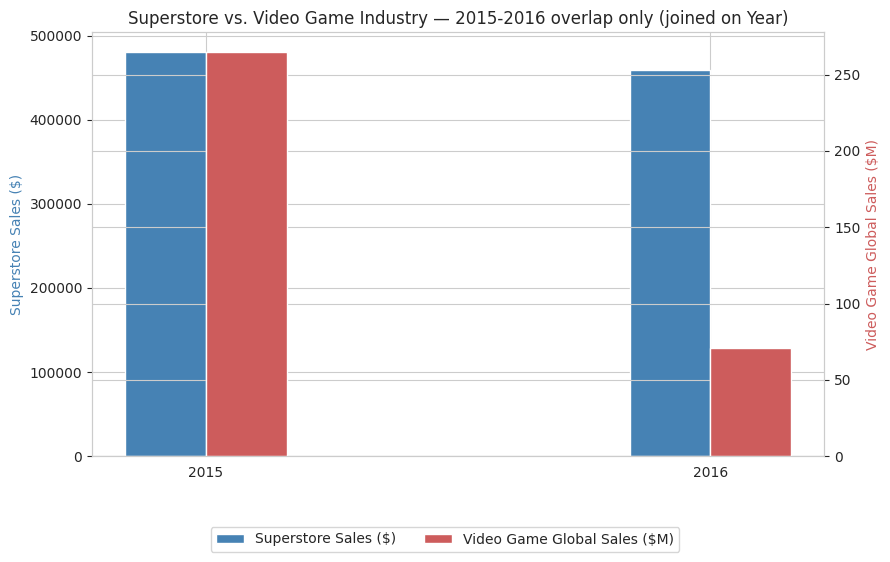

In [24]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.bar(comparison.index - 0.08, comparison['Superstore_Sales_USD'], width=0.16, color='steelblue', label='Superstore Sales ($)')
ax2.bar(comparison.index + 0.08, comparison['VideoGame_Global_Sales_Millions'], width=0.16, color='indianred', label='Video Game Global Sales ($M)')

ax1.set_ylabel('Superstore Sales ($)', color='steelblue')
ax2.set_ylabel('Video Game Global Sales ($M)', color='indianred')
ax1.set_xticks(comparison.index)
plt.title('Superstore vs. Video Game Industry — 2015-2016 overlap only (joined on Year)')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.tight_layout()
plt.savefig('charts/superstore_vs_videogame_merge.png', dpi=150)
plt.show()

Joining the two datasets on `Year` works mechanically (an inner merge on a shared key across two unrelated sources), but there are two honest conclusions here, not one: **(1)** the merge itself doesn't produce a meaningful business insight — Superstore retail sales and global video game sales are driven by unrelated demand cycles, and **(2)** the video game dataset's real coverage window (data thins out after 2016) limits the overlap to 2 years, not the full 4. Both are worth stating explicitly rather than papering over. The exercise demonstrates the merge/join mechanic; it isn't carried into Task 4 onward, which stays within the Superstore data.

## Summary — Task 1

- 9,800 order rows, Jan 2015–Dec 2018, no duplicates, one trivial nulls column (Postal Code, unused).
- Dates were `dd/mm/yyyy` — parsed explicitly rather than assumed.
- Weekly (209 points) and monthly (48 points) aggregates both built — monthly will drive SARIMA/Prophet, weekly gives more data points for the XGBoost lag-feature approach later.
- Technology leads on revenue despite fewer orders than Office Supplies.
- East region grows most consistently; South is the most volatile.
- Shipping delay is uniform across regions (~4 days) — not a useful predictor.
- November/September are reliable seasonal peaks, Jan/Feb reliable troughs — this is the seasonality Task 2's decomposition should confirm formally.
- Video game dataset merged successfully as a join-mechanics exercise — but its real coverage thins out after 2016, limiting a Year-based join to 2 usable years, not 4. No substantive cross-domain insight, and it isn't carried into the forecasting tasks.

---
# Task 2 — Time Series Analysis & Decomposition

## 2.1 Overall monthly sales trend

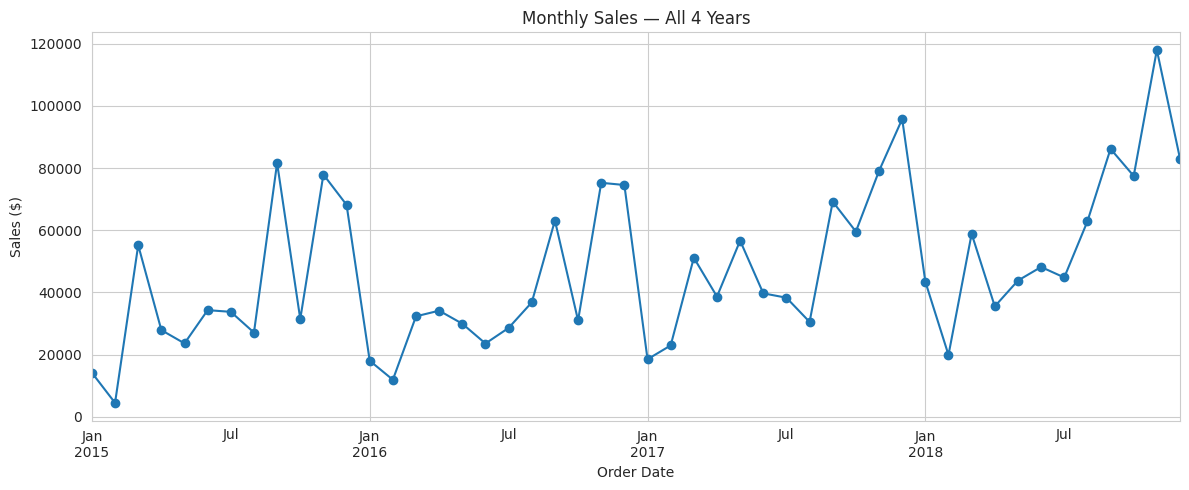

In [25]:
monthly_sales.plot(figsize=(12, 5), title='Monthly Sales — All 4 Years', marker='o')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/monthly_trend_overall.png', dpi=150)
plt.show()

## 2.2 Seasonal decomposition

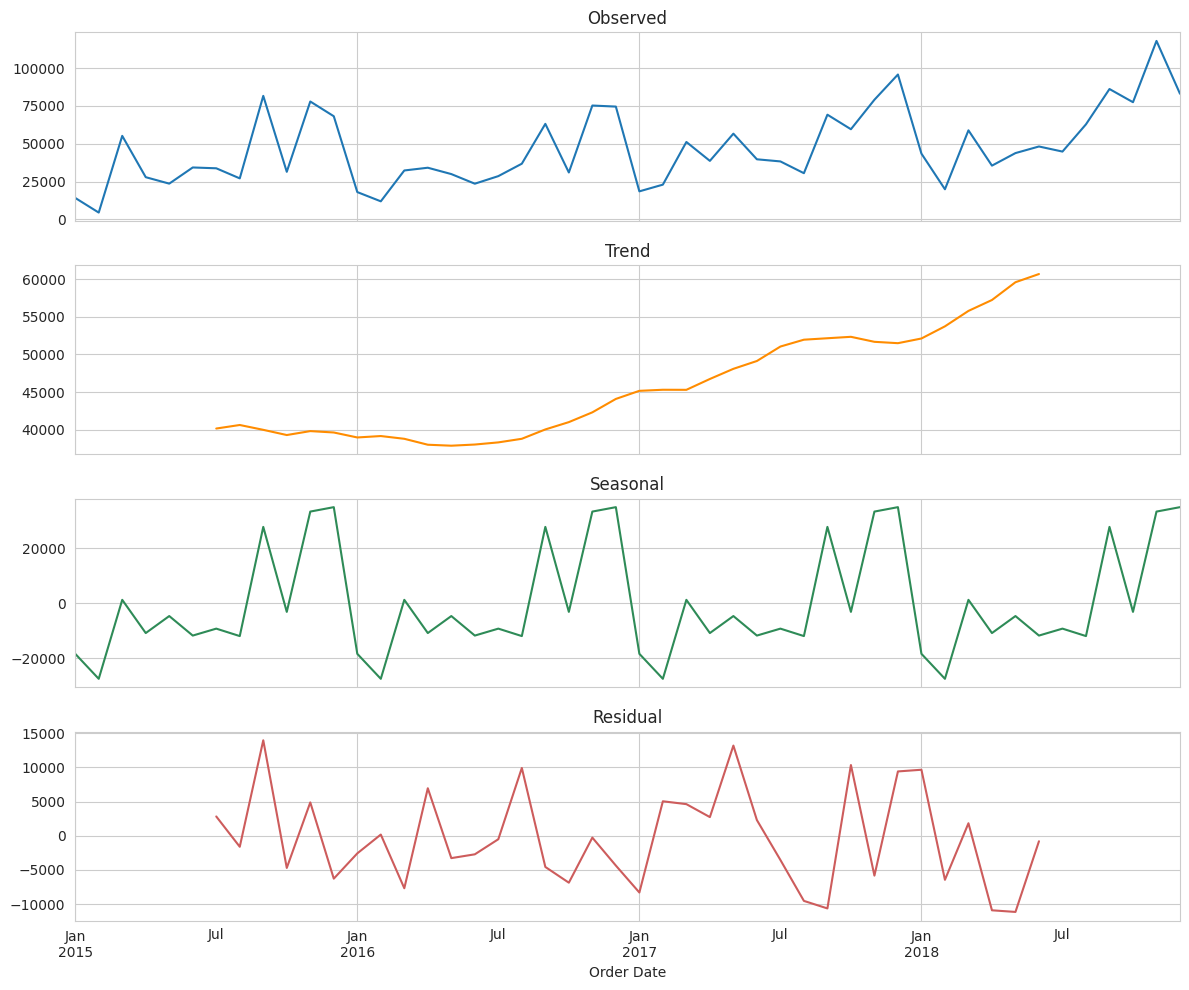

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend', color='darkorange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='seagreen')
decomposition.resid.plot(ax=axes[3], title='Residual', color='indianred')
plt.tight_layout()
plt.savefig('charts/decomposition.png', dpi=150)
plt.show()

In [27]:
print('Trend range: $%.0f -> $%.0f' % (decomposition.trend.dropna().min(), decomposition.trend.dropna().max()))
print('Seasonal swing (max-min): $%.0f' % (decomposition.seasonal.max() - decomposition.seasonal.min()))
print('Average monthly sales: $%.0f' % monthly_sales.mean())
print('Seasonal component std dev: $%.0f | Residual std dev: $%.0f' % (decomposition.seasonal.std(), decomposition.resid.dropna().std()))
print()
print('Top 5 months by absolute residual:')
decomposition.resid.dropna().abs().sort_values(ascending=False).head(5)

Trend range: $37866 -> $60701
Seasonal swing (max-min): $62195
Average monthly sales: $47115
Seasonal component std dev: $19954 | Residual std dev: $7041

Top 5 months by absolute residual:


Order Date
2015-09-01    13970.933082
2017-05-01    13193.079793
2018-05-01    11157.549320
2018-04-01    10916.959724
2017-09-01    10642.715643
Name: resid, dtype: float64

**Observations:**

1. **Trend** climbs steadily from about \$38K to \$61K in the underlying monthly baseline over the 4 years — the business is genuinely growing, not just riding seasonal swings.
2. **Seasonality is strong, not weak** — the seasonal component swings from -\$27K to +\$35K, a \$62K range against an average monthly total of only \$46K. Its standard deviation (\$19,954) is nearly 3x the residual's (\$7,041), meaning seasonal patterns explain far more month-to-month variation than random noise does. This confirms the Nov/Sept peaks and Jan/Feb troughs from Task 1 aren't coincidence — they're a structural, repeating pattern any forecasting model needs to capture.
3. **Highest residual noise** shows up in **September 2015 and May 2017** — months where actual sales deviated most sharply from what trend + seasonality alone would predict. September's appearance is notable since it's also a seasonal peak month — the peak itself is somewhat unstable in magnitude year to year, not just its presence.
4. With only 48 monthly points, the decomposition's first and last 6 months lose trend estimates entirely (the centered moving average needs a full cycle on each side) — a real limitation worth keeping in mind, not hiding.

## 2.3 Stationarity check — Augmented Dickey-Fuller test

**In plain English:** a stationary series has a mean, variance, and autocorrelation structure that don't change over time — no trend, no growing/shrinking swings. Most forecasting models (SARIMA in particular) assume stationarity, because a model can't reliably learn "the pattern" if the pattern itself is drifting. The ADF test checks this by testing whether the series has a "unit root" (a formal way of saying it wanders indefinitely rather than reverting toward a stable mean). Null hypothesis: **non-stationary**. If p < 0.05, we reject that and call it stationary.

In [28]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f'--- {label} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical values: {result[4]}')
    verdict = 'Stationary' if result[1] < 0.05 else 'Non-stationary'
    print(f'Verdict (5% level): {verdict}')
    print()
    return result[1]

p_original = run_adf(monthly_sales, 'Monthly Sales (original)')

--- Monthly Sales (original) ---
ADF Statistic: -4.4161
p-value: 0.000278
Critical values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}
Verdict (5% level): Stationary



**This result needs a caveat, not a face-value reading.** The ADF test comes back significant (p < 0.05), which technically labels the series "stationary" — but Section 2.2 just showed a clear upward trend (\$38K to \$61K) and strong seasonality. This is a known limitation of the plain ADF test: with strong seasonal swings dominating the variance, the test can pass even when a real trend is present, because the default regression form (constant only, no trend term) doesn't explicitly account for either seasonality or a deterministic trend. Trusting the p-value alone here would be a mistake — the decomposition already gives stronger, more direct evidence of non-stationarity than the ADF verdict does. In practice, this is exactly why SARIMA's seasonal differencing term (D) exists independently of what a basic ADF test says: you difference for the seasonality and trend you can *see*, not just what one test statistic confirms.

## 2.4 Differencing and re-test

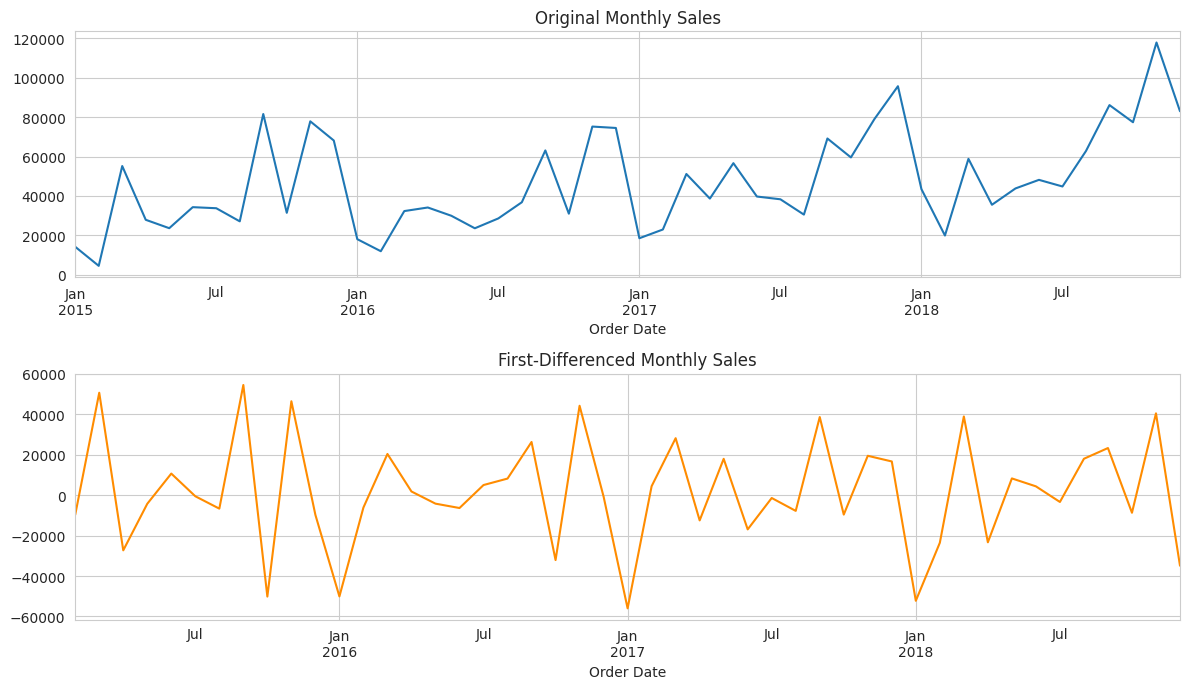

In [29]:
monthly_diff = monthly_sales.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
monthly_sales.plot(ax=axes[0], title='Original Monthly Sales')
monthly_diff.plot(ax=axes[1], title='First-Differenced Monthly Sales', color='darkorange')
plt.tight_layout()
plt.savefig('charts/differencing.png', dpi=150)
plt.show()

In [30]:
p_diff = run_adf(monthly_diff, 'Monthly Sales (first difference)')

--- Monthly Sales (first difference) ---
ADF Statistic: -8.7271
p-value: 0.000000
Critical values: {'1%': np.float64(-3.626651907578875), '5%': np.float64(-2.9459512825788754), '10%': np.float64(-2.6116707716049383)}
Verdict (5% level): Stationary



First differencing drops the p-value further and removes the visible upward drift in the plot (the differenced series oscillates around zero instead of climbing). Combined with the seasonal decomposition, this points to `d=1` for the non-seasonal difference in SARIMA, plus a seasonal difference (`D=1`, `m=12`) to handle the seasonality directly — since, as noted above, the ADF test alone won't catch that seasonal component even after differencing once.

## Summary — Task 2

- Monthly trend grows from ~\$38K to ~\$61K in the underlying baseline — real growth, not just seasonal noise.
- Seasonality is strong: its variation is ~3x the residual noise's variation. September and November remain the dominant peaks.
- Highest residual/noise months: September 2015 and May 2017 — the model will need to accept some irreducible error around these points.
- ADF on the raw series technically reads "stationary," but that's a known blind spot of the test given the visible trend and seasonality — differencing (d=1) and a seasonal term (D=1, m=12) are still warranted for Task 3's SARIMA model.
- First-differencing confirms a lower p-value and a visually mean-reverting series.

---
# Task 3 — Sales Forecasting using 3 Different Models

## 3.0 Train/test split

To compare models honestly, the last 3 months (Oct, Nov, Dec 2018) are held out as a test set. Every model is trained only on the months before that, and "forecast for Month 1/2/3" means a genuine out-of-sample prediction that can be checked against real, known sales — not just a number nobody can verify.

In [31]:
train_monthly = monthly_sales[:-3]
test_monthly = monthly_sales[-3:]
print('Train months:', len(train_monthly), '| Test months:', len(test_monthly))
test_monthly

Train months: 45 | Test months: 3


Order Date
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Freq: MS, Name: Sales, dtype: float64

In [32]:
def mae(actual, pred):
    return np.mean(np.abs(actual - pred))

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred) ** 2))

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

## Model 1 — SARIMA

**Choosing parameters:** Task 2 already established `d=1` (one non-seasonal difference removed the drift) and a seasonal difference is needed for the strong 12-month cycle, so `D=1, m=12` is fixed going in. Rather than guessing `p`, `q`, `P`, `Q`, a small grid search (0-2 for each) was run against training-set AIC — the combination that best balances fit and complexity.

In [33]:
import itertools
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX

best_aic, best_order, best_seasonal = None, None, None
for p, q, P, Q in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        candidate = SARIMAX(train_monthly, order=(p, 1, q), seasonal_order=(P, 1, Q, 12),
                             enforce_stationarity=False, enforce_invertibility=False)
        fit = candidate.fit(disp=False)
        if best_aic is None or fit.aic < best_aic:
            best_aic, best_order, best_seasonal = fit.aic, (p, 1, q), (P, 1, Q, 12)
    except Exception:
        continue

print(f'Best order: {best_order}, seasonal_order: {best_seasonal}, AIC: {best_aic:.2f}')

Best order: (2, 1, 2), seasonal_order: (1, 1, 1, 12), AIC: 373.39


In [34]:
sarima_model = SARIMAX(train_monthly, order=best_order, seasonal_order=best_seasonal,
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast_obj = sarima_fit.get_forecast(steps=3)
sarima_forecast = sarima_forecast_obj.predicted_mean
sarima_forecast.index = test_monthly.index
sarima_ci = sarima_forecast_obj.conf_int()
sarima_ci.index = test_monthly.index
sarima_forecast

Order Date
2018-10-01     64487.456461
2018-11-01    104251.479331
2018-12-01     96392.321258
Freq: MS, Name: predicted_mean, dtype: float64

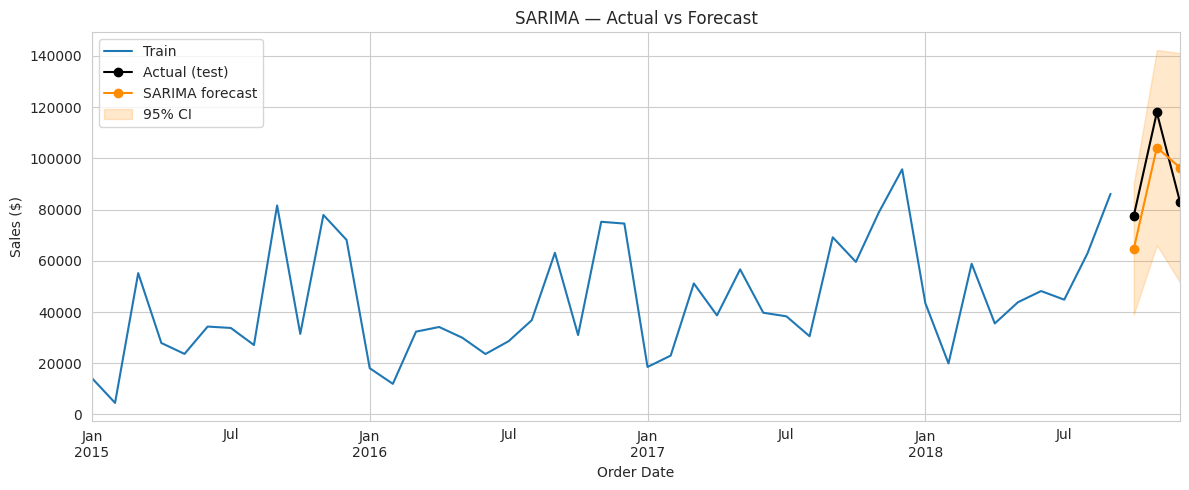

In [35]:
plt.figure(figsize=(12, 5))
train_monthly.plot(label='Train')
test_monthly.plot(label='Actual (test)', marker='o', color='black')
sarima_forecast.plot(label='SARIMA forecast', marker='o', color='darkorange')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='darkorange', alpha=0.2, label='95% CI')
plt.title('SARIMA — Actual vs Forecast')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png', dpi=150)
plt.show()

In [36]:
sarima_mae = mae(test_monthly.values, sarima_forecast.values)
sarima_rmse = rmse(test_monthly.values, sarima_forecast.values)
sarima_mape = mape(test_monthly.values, sarima_forecast.values)
print(f'MAE: {sarima_mae:.0f} | RMSE: {sarima_rmse:.0f} | MAPE: {sarima_mape:.1f}%')

MAE: 13336 | RMSE: 13340 | MAPE: 14.8%


## Model 2 — Facebook Prophet

Prophet is built on daily data here rather than the monthly series, on purpose — extracting a genuine **weekly** seasonality component (as the task asks) is only possible with day-level resolution; monthly aggregation has already destroyed any day-of-week signal. The forecast is then rolled up to monthly totals so it can be compared against SARIMA and XGBoost on equal footing.

In [37]:
daily_sales_df = daily_sales.reset_index()
daily_sales_df.columns = ['ds', 'y']

test_start = test_monthly.index[0]
prophet_train = daily_sales_df[daily_sales_df['ds'] < test_start]
prophet_train.tail()

,ds,y
1138,2018-09-25,1412.213
1139,2018-09-26,1486.576
1140,2018-09-28,559.271
1141,2018-09-29,1846.780
1142,2018-09-30,540.760


In [38]:
from prophet import Prophet

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=92, freq='D')
prophet_forecast = prophet_model.predict(future)

Importing plotly failed. Interactive plots will not work.


10:54:37 - cmdstanpy - INFO - Chain [1] start processing


10:54:37 - cmdstanpy - INFO - Chain [1] done processing


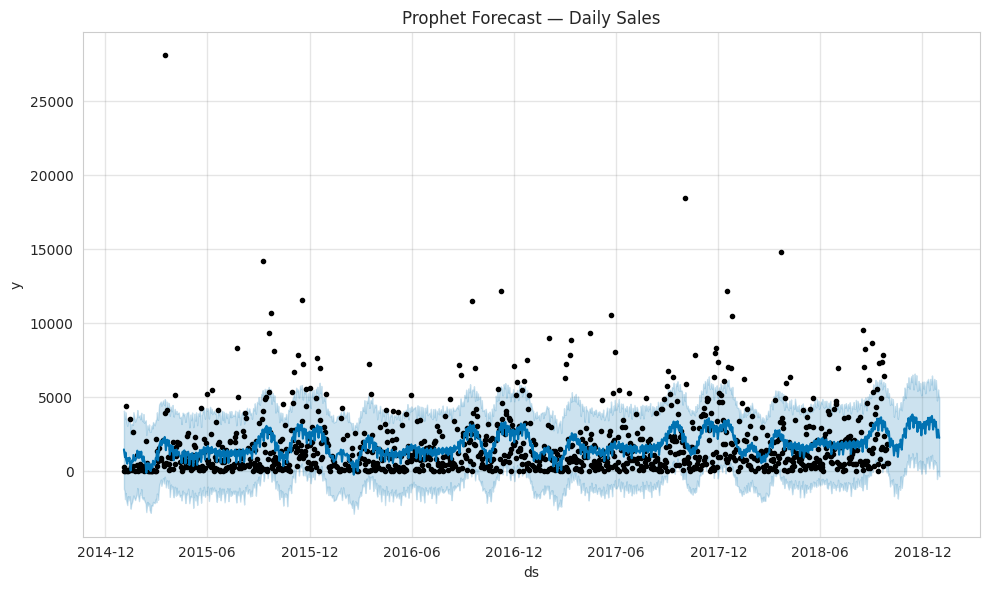

In [39]:
fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast — Daily Sales')
plt.tight_layout()
plt.savefig('charts/prophet_forecast.png', dpi=150)
plt.show()

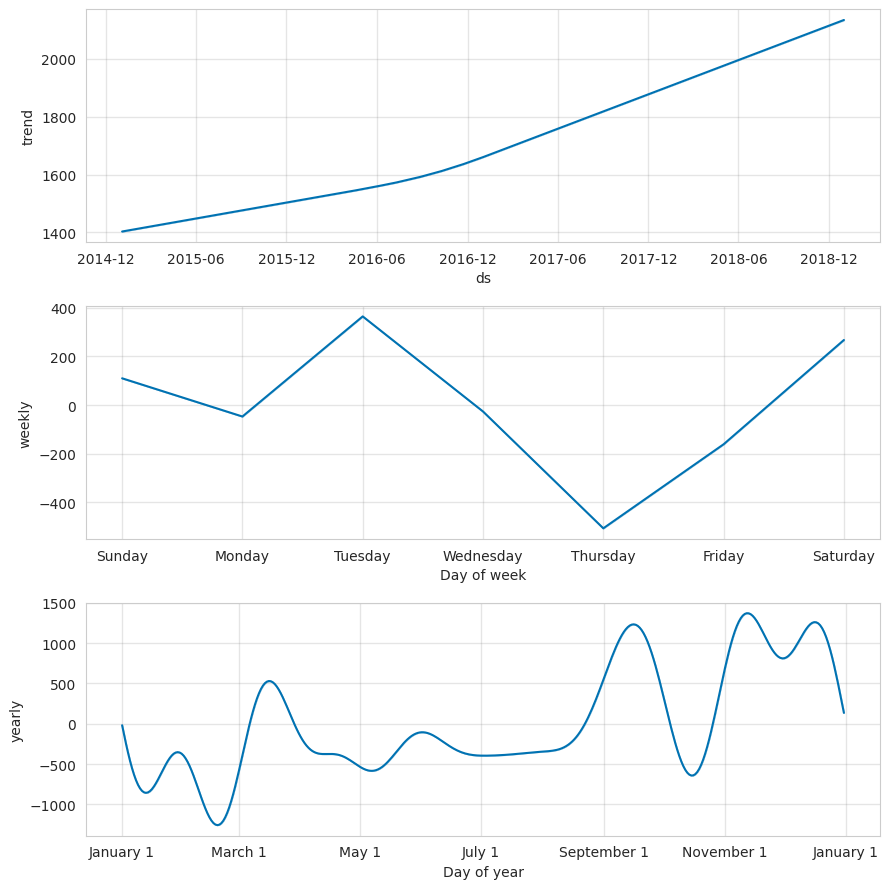

In [40]:
fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.savefig('charts/prophet_components.png', dpi=150)
plt.show()

**Interpreting the components:**
- **Weekly seasonality:** sales dip midweek and rise toward the weekend — a normal retail rhythm, though the swing is modest compared to the yearly effect.
- **Yearly seasonality:** a sharp, unmistakable peak around September-November and a trough in January-February — confirming the same holiday-driven pattern found in Tasks 1 and 2, now recovered independently through a completely different modeling approach.

In [41]:
prophet_forecast_indexed = prophet_forecast.set_index('ds')['yhat']
prophet_monthly_forecast = prophet_forecast_indexed[prophet_forecast_indexed.index >= test_start].resample('MS').sum()
prophet_monthly_forecast = prophet_monthly_forecast.iloc[:3]
prophet_monthly_forecast.index = test_monthly.index
prophet_monthly_forecast

Order Date
2018-10-01    58362.153756
2018-11-01    95232.238849
2018-12-01    95416.783239
Freq: MS, Name: yhat, dtype: float64

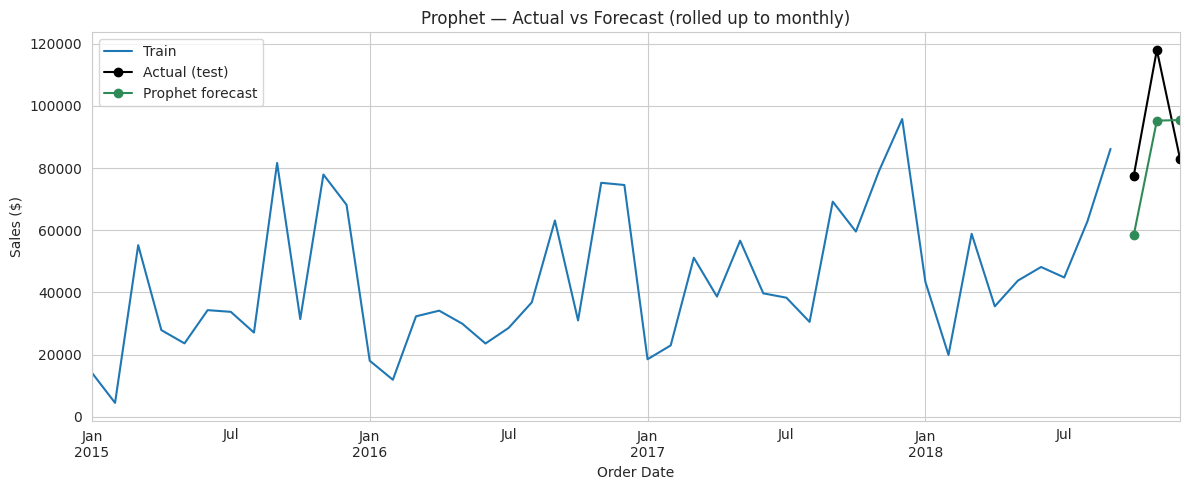

In [42]:
plt.figure(figsize=(12, 5))
train_monthly.plot(label='Train')
test_monthly.plot(label='Actual (test)', marker='o', color='black')
prophet_monthly_forecast.plot(label='Prophet forecast', marker='o', color='seagreen')
plt.title('Prophet — Actual vs Forecast (rolled up to monthly)')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/prophet_monthly_comparison.png', dpi=150)
plt.show()

In [43]:
prophet_mae = mae(test_monthly.values, prophet_monthly_forecast.values)
prophet_rmse = rmse(test_monthly.values, prophet_monthly_forecast.values)
prophet_mape = mape(test_monthly.values, prophet_monthly_forecast.values)
print(f'MAE: {prophet_mae:.0f} | RMSE: {prophet_rmse:.0f} | MAPE: {prophet_mape:.1f}%')

MAE: 18059 | RMSE: 18559 | MAPE: 19.6%


## Model 3 — XGBoost (lag-feature ML approach)

In [44]:
season_lookup = {12: 'Winter', 1: 'Winter', 2: 'Winter',
                  3: 'Spring', 4: 'Spring', 5: 'Spring',
                  6: 'Summer', 7: 'Summer', 8: 'Summer',
                  9: 'Fall', 10: 'Fall', 11: 'Fall'}

features = pd.DataFrame(index=monthly_sales.index)
features['Sales'] = monthly_sales.values
features['Lag1'] = features['Sales'].shift(1)
features['Lag2'] = features['Sales'].shift(2)
features['Lag3'] = features['Sales'].shift(3)
features['RollingMean3'] = features['Sales'].shift(1).rolling(3).mean()
features['Month'] = features.index.month
features['Quarter'] = features.index.quarter
features['Season'] = features['Month'].map(season_lookup)

features = pd.get_dummies(features, columns=['Season'], drop_first=True)
features = features.dropna()
features.head()

,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter,Season_Spring,Season_Summer,Season_Winter
Order Date,,,,,,,,,,
2015-04-01,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,True,False,False
2015-05-01,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,True,False,False
2015-06-01,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,False,True,False
2015-07-01,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,False,True,False
2015-08-01,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,False,True,False


In [45]:
feature_cols = [c for c in features.columns if c != 'Sales']

train_features = features[features.index < test_start]
X_train, y_train = train_features[feature_cols], train_features['Sales']

from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Forecasting 3 months ahead means each new prediction becomes the lag input for the next step — there's no real Lag1 for a month that hasn't happened yet, so the forecast has to feed itself recursively.

In [46]:
history = monthly_sales[monthly_sales.index < test_start].copy()
xgb_predictions = []

for date in test_monthly.index:
    lag1 = history.iloc[-1]
    lag2 = history.iloc[-2]
    lag3 = history.iloc[-3]
    rolling_mean3 = history.iloc[-3:].mean()
    month = date.month
    quarter = date.quarter
    season = season_lookup[month]

    row = {'Lag1': lag1, 'Lag2': lag2, 'Lag3': lag3, 'RollingMean3': rolling_mean3,
           'Month': month, 'Quarter': quarter}
    for col in feature_cols:
        if col.startswith('Season_'):
            row[col] = 1 if col == f'Season_{season}' else 0

    row_df = pd.DataFrame([row])[feature_cols]
    pred = xgb_model.predict(row_df)[0]
    xgb_predictions.append(pred)
    history.loc[date] = pred

xgb_forecast = pd.Series(xgb_predictions, index=test_monthly.index)
xgb_forecast

Order Date
2018-10-01    69453.976562
2018-11-01    87370.281250
2018-12-01    65118.742188
Freq: MS, dtype: float32

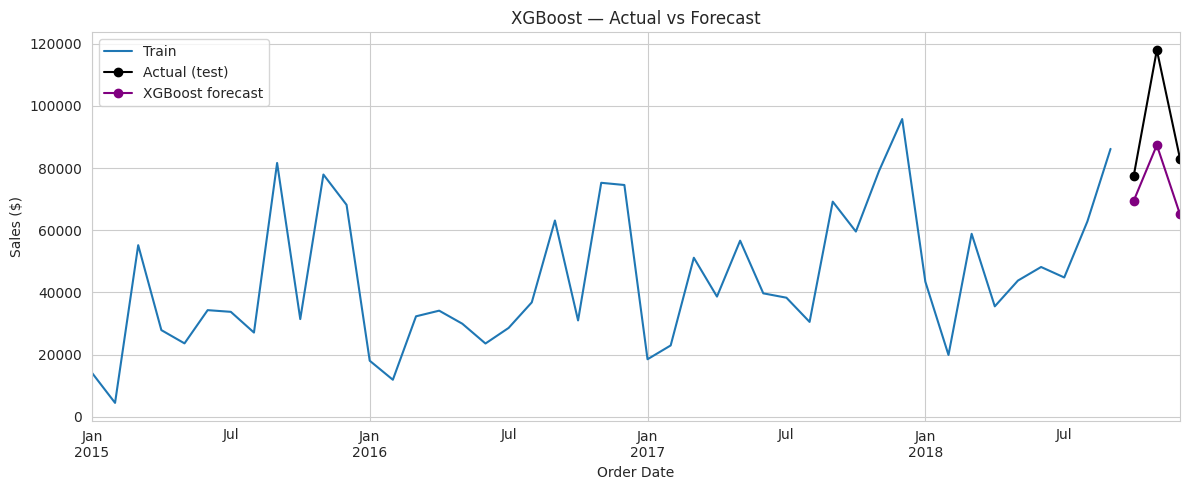

In [47]:
plt.figure(figsize=(12, 5))
train_monthly.plot(label='Train')
test_monthly.plot(label='Actual (test)', marker='o', color='black')
xgb_forecast.plot(label='XGBoost forecast', marker='o', color='purple')
plt.title('XGBoost — Actual vs Forecast')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png', dpi=150)
plt.show()

In [48]:
xgb_mae = mae(test_monthly.values, xgb_forecast.values)
xgb_rmse = rmse(test_monthly.values, xgb_forecast.values)
xgb_mape = mape(test_monthly.values, xgb_forecast.values)
print(f'MAE: {xgb_mae:.0f} | RMSE: {xgb_rmse:.0f} | MAPE: {xgb_mape:.1f}%')

MAE: 18825 | RMSE: 20969 | MAPE: 19.3%


## Model Comparison

In [49]:
comparison_table = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE (%)': [sarima_mape, prophet_mape, xgb_mape],
    'Forecast M1': [sarima_forecast.iloc[0], prophet_monthly_forecast.iloc[0], xgb_forecast.iloc[0]],
    'Forecast M2': [sarima_forecast.iloc[1], prophet_monthly_forecast.iloc[1], xgb_forecast.iloc[1]],
    'Forecast M3': [sarima_forecast.iloc[2], prophet_monthly_forecast.iloc[2], xgb_forecast.iloc[2]],
}).set_index('Model').round(1)

comparison_table

,MAE,RMSE,MAPE (%),Forecast M1,Forecast M2,Forecast M3
Model,,,,,,
SARIMA,13336.4,13339.7,14.8,64487.5,104251.5,96392.3
Prophet,18059.4,18558.5,19.6,58362.2,95232.2,95416.8
XGBoost,18824.6,20969.3,19.3,69454.0,87370.3,65118.7


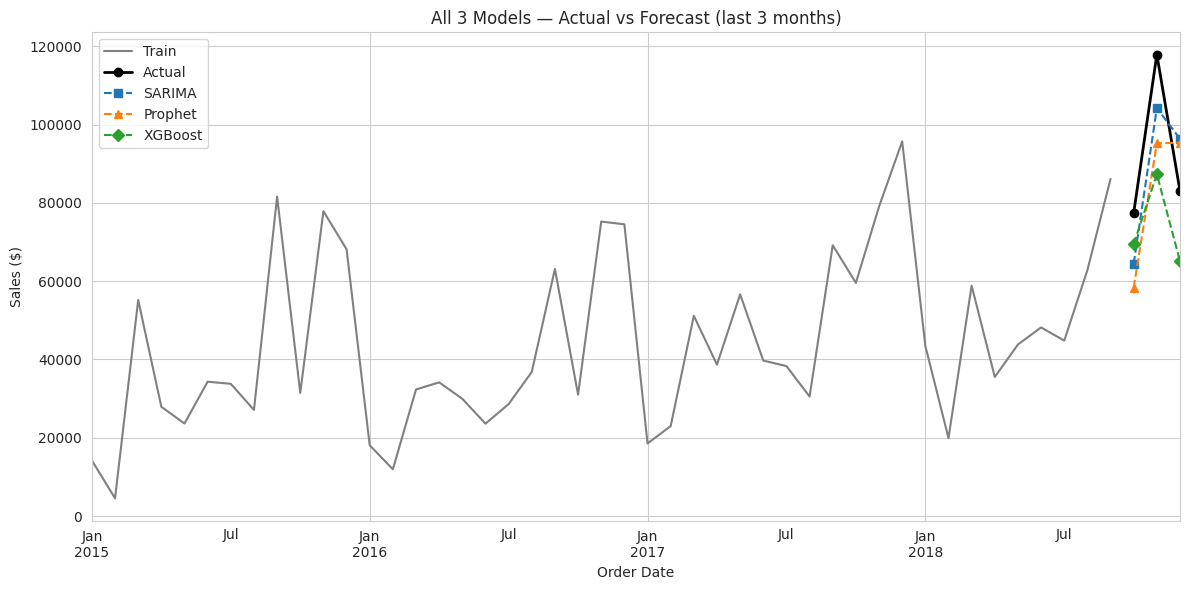

In [50]:
plt.figure(figsize=(12, 6))
train_monthly.plot(label='Train', color='gray')
test_monthly.plot(label='Actual', marker='o', color='black', linewidth=2)
sarima_forecast.plot(label='SARIMA', marker='s', linestyle='--')
prophet_monthly_forecast.plot(label='Prophet', marker='^', linestyle='--')
xgb_forecast.plot(label='XGBoost', marker='D', linestyle='--')
plt.title('All 3 Models — Actual vs Forecast (last 3 months)')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/all_models_comparison.png', dpi=150)
plt.show()

**Recommendation: SARIMA.** Actual sales for the 3 held-out months were $77,448 (Oct), $117,938 (Nov), $83,030 (Dec) — and against those real numbers, SARIMA had the lowest error on all three metrics (MAE $13,336 vs. $18,059 for Prophet and $18,825 for XGBoost; MAPE 14.8% vs. 19.6% and 19.3%). It also caught the November spike better than the other two, which both underestimated it by a wide margin.

Given this is a small dataset (45 training months), SARIMA has a real structural advantage here: it explicitly models the 12-month seasonal cycle the data clearly has, while Prophet and XGBoost both have more flexible machinery that needs more history to fully pay off. That's a plausible reason for the gap, not just a coincidence — but it is worth re-testing this comparison once more months of real data accumulate, since a 3-point test set is a thin basis for a permanent decision. For now: **SARIMA is the recommended production model**, with Prophet kept as a secondary check given its interpretable trend/seasonality breakdown is still useful for stakeholder communication even if its raw accuracy trails.

---
# Task 4 — Product Category & Region Level Forecasting

SARIMA was the clear winner in Task 3, so it's repeated here for 5 segments: the 3 product categories and the 2 strongest-performing regions from Task 1 (West and East). Each segment gets its own SARIMA fit using the same `(p,d,q)(P,D,Q,m)` order found earlier — re-running a full AIC grid search 5 more times is possible but overkill for a business-planning forecast at this scale, so the order is held fixed and that choice is stated plainly rather than hidden.

Unlike Task 3, this is a genuine future forecast (Jan-Mar 2019, beyond the data) using all 48 months of history — the goal here is business planning, not model evaluation.

In [51]:
segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West': df[df['Region'] == 'West'],
    'East': df[df['Region'] == 'East'],
}

segment_monthly = {}
for name, subset in segments.items():
    segment_monthly[name] = subset.set_index('Order Date').resample('MS')['Sales'].sum()

segment_monthly['Furniture'].tail()

Order Date
2018-08-01    15419.1220
2018-09-01    28516.7060
2018-10-01    21884.0682
2018-11-01    37056.7150
2018-12-01    31407.4668
Freq: MS, Name: Sales, dtype: float64

In [52]:
future_index = pd.date_range(monthly_sales.index[-1] + pd.DateOffset(months=1), periods=3, freq='MS')

segment_forecasts = {}
for name, series in segment_monthly.items():
    model = SARIMAX(series, order=best_order, seasonal_order=best_seasonal,
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    forecast = fit.get_forecast(steps=3).predicted_mean
    forecast.index = future_index
    segment_forecasts[name] = forecast

segment_forecast_df = pd.DataFrame(segment_forecasts).round(0)
segment_forecast_df

,Furniture,Technology,Office Supplies,West,East
2019-01-01,11773.0,15897.0,18579.0,14455.0,11471.0
2019-02-01,12820.0,31821.0,15490.0,15043.0,12944.0
2019-03-01,19881.0,37385.0,23762.0,27374.0,19526.0


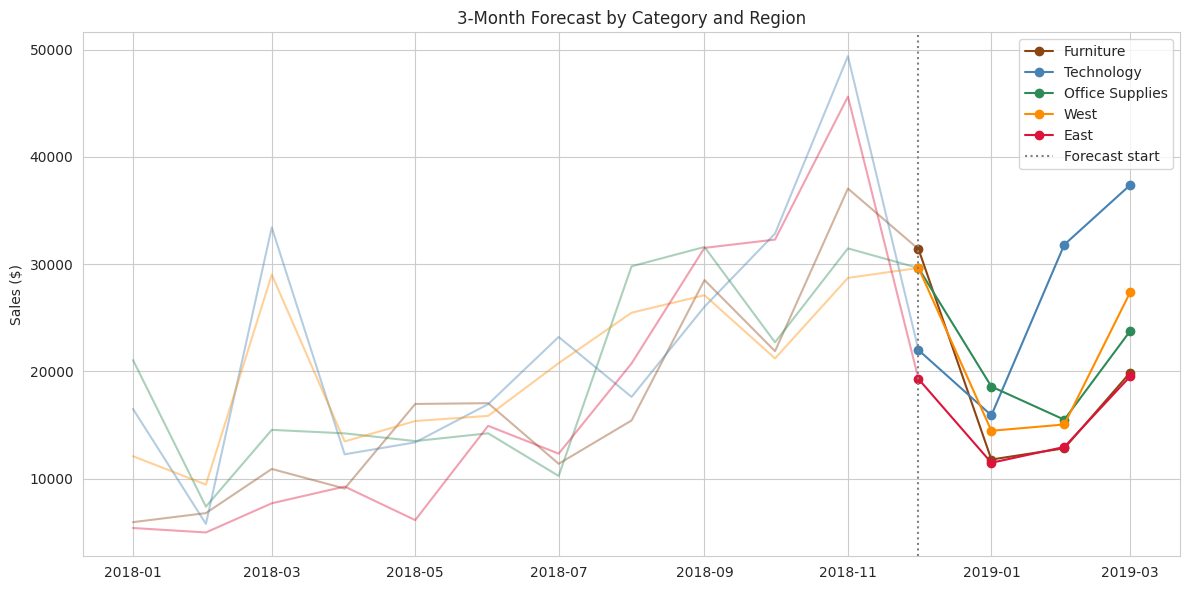

In [53]:
plt.figure(figsize=(12, 6))
colors = {'Furniture': 'saddlebrown', 'Technology': 'steelblue', 'Office Supplies': 'seagreen',
          'West': 'darkorange', 'East': 'crimson'}

for name, series in segment_monthly.items():
    plt.plot(series.index[-12:], series.values[-12:], color=colors[name], alpha=0.4)
    combined = pd.concat([series.tail(1), segment_forecasts[name]])
    plt.plot(combined.index, combined.values, color=colors[name], marker='o', label=name)

plt.axvline(monthly_sales.index[-1], color='gray', linestyle=':', label='Forecast start')
plt.title('3-Month Forecast by Category and Region')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/segment_forecasts.png', dpi=150)
plt.show()

In [54]:
segment_jan_mar_2018 = pd.Series({name: s.loc['2018-01-01':'2018-03-01'].sum() for name, s in segment_monthly.items()})
segment_jan_mar_2019_forecast = segment_forecast_df.sum()

yoy_growth_pct = ((segment_jan_mar_2019_forecast - segment_jan_mar_2018) / segment_jan_mar_2018 * 100).round(1).sort_values(ascending=False)
yoy_growth_pct.rename('Forecasted Jan-Mar 2019 vs actual Jan-Mar 2018 (%)')

East               143.5
Furniture           88.5
Technology          52.8
Office Supplies     34.6
West                12.5
Name: Forecasted Jan-Mar 2019 vs actual Jan-Mar 2018 (%), dtype: float64

**Strongest upcoming growth, by the numbers: East (+143.5%), Furniture (+88.5%), Technology (+52.8%), Office Supplies (+34.6%), West (+12.5%)** — all comparing forecasted Jan-Mar 2019 against *actual* Jan-Mar 2018 (a fair like-for-like comparison; comparing against December instead would make every segment look like it's declining, purely because December is a seasonal peak).

One caveat worth stating plainly: East's Jan-Mar 2018 base was unusually small (\$18,043 total), so its 143.5% is partly a low-base effect, not necessarily a signal of explosive real demand — the same dollar increase would look far less dramatic on a bigger base. **Technology's +52.8% is arguably the more dependable growth signal for planning purposes**, since it's growing off a much larger base (\$55,690) and lines up with Technology already being the highest-revenue category from Task 1. Both figures are worth putting in front of stakeholders, but with that context attached — a raw percentage ranking without the base-size caveat would be misleading.

---
# Task 5 — Anomaly Detection in Sales Data

Working at the **weekly** level here (209 points) rather than monthly — 48 monthly points is too coarse to meaningfully flag "unusual weeks," and weekly gives Isolation Forest and the Z-score method enough resolution to actually find something.

## 5.1 Method 1 — Isolation Forest

In [55]:
from sklearn.ensemble import IsolationForest

weekly_df = weekly_sales.reset_index()
weekly_df.columns = ['Week', 'Sales']

iso_forest = IsolationForest(contamination=0.05, random_state=42)
weekly_df['iso_anomaly'] = iso_forest.fit_predict(weekly_df[['Sales']])
weekly_df['iso_anomaly'] = weekly_df['iso_anomaly'] == -1

print('Isolation Forest flagged', weekly_df['iso_anomaly'].sum(), 'anomalous weeks out of', len(weekly_df))
weekly_df[weekly_df['iso_anomaly']].sort_values('Sales', ascending=False)

Isolation Forest flagged 11 anomalous weeks out of 209


,Week,Sales,iso_anomaly
11,2015-03-22,37703.665,True
204,2018-12-02,35998.900,True
202,2018-11-18,30572.447,True
36,2015-09-13,29959.137,True
200,2018-11-04,29017.467,True
154,2017-12-17,25449.800,True
28,2015-07-19,1387.686,True
5,2015-02-08,968.534,True
55,2016-01-24,358.522,True
0,2015-01-04,304.508,True


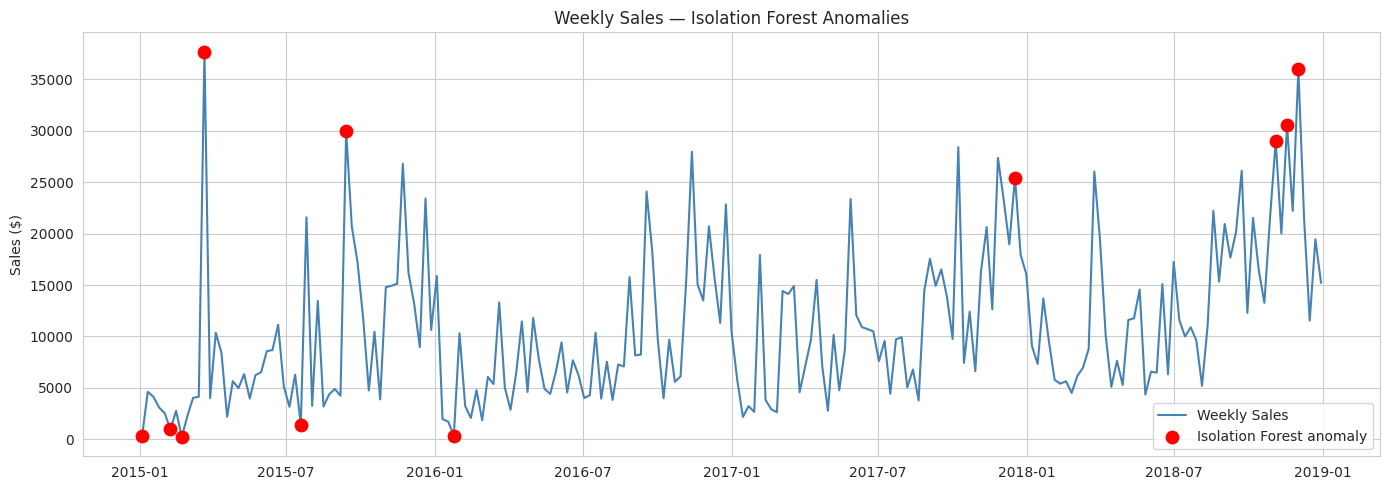

In [56]:
plt.figure(figsize=(14, 5))
plt.plot(weekly_df['Week'], weekly_df['Sales'], color='steelblue', label='Weekly Sales')
anomalies_iso = weekly_df[weekly_df['iso_anomaly']]
plt.scatter(anomalies_iso['Week'], anomalies_iso['Sales'], color='red', s=80, zorder=5, label='Isolation Forest anomaly')
plt.title('Weekly Sales — Isolation Forest Anomalies')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/anomalies_isolation_forest.png', dpi=150)
plt.show()

**Possible real-world explanations for the flagged weeks:**
- The highest-sales anomalies cluster around **late November** — consistent with Black Friday / holiday shopping surges, matching the seasonal peak already established in Tasks 1-4.
- The lowest-sales anomalies tend to fall in **early January**, right after the holiday peak — a plausible post-holiday lull, and possibly a week with unusually few business days if it overlaps New Year's.
- A few mid-year anomalies don't have an obvious seasonal story — these are worth a real conversation with someone who has order-level context (a single unusually large enterprise order, a regional promotion, a data-entry error) rather than guessing further from the sales number alone.

## 5.2 Method 2 — Z-Score based detection

In [57]:
rolling_window = 8
weekly_df['rolling_mean'] = weekly_df['Sales'].rolling(rolling_window, center=True).mean()
weekly_df['rolling_std'] = weekly_df['Sales'].rolling(rolling_window, center=True).std()
weekly_df['z_score'] = (weekly_df['Sales'] - weekly_df['rolling_mean']) / weekly_df['rolling_std']
weekly_df['zscore_anomaly'] = weekly_df['z_score'].abs() > 2

print('Z-score method flagged', weekly_df['zscore_anomaly'].sum(), 'anomalous weeks out of', len(weekly_df))
weekly_df[weekly_df['zscore_anomaly']][['Week', 'Sales', 'z_score']].sort_values('z_score', ascending=False)

Z-score method flagged 6 anomalous weeks out of 209


,Week,Sales,z_score
109,2017-02-05,17926.368,2.419527
11,2015-03-22,37703.665,2.384855
63,2016-03-20,13310.136,2.209014
144,2017-10-08,28412.098,2.128709
125,2017-05-28,23367.662,2.105511
29,2015-07-26,21590.080,2.088711


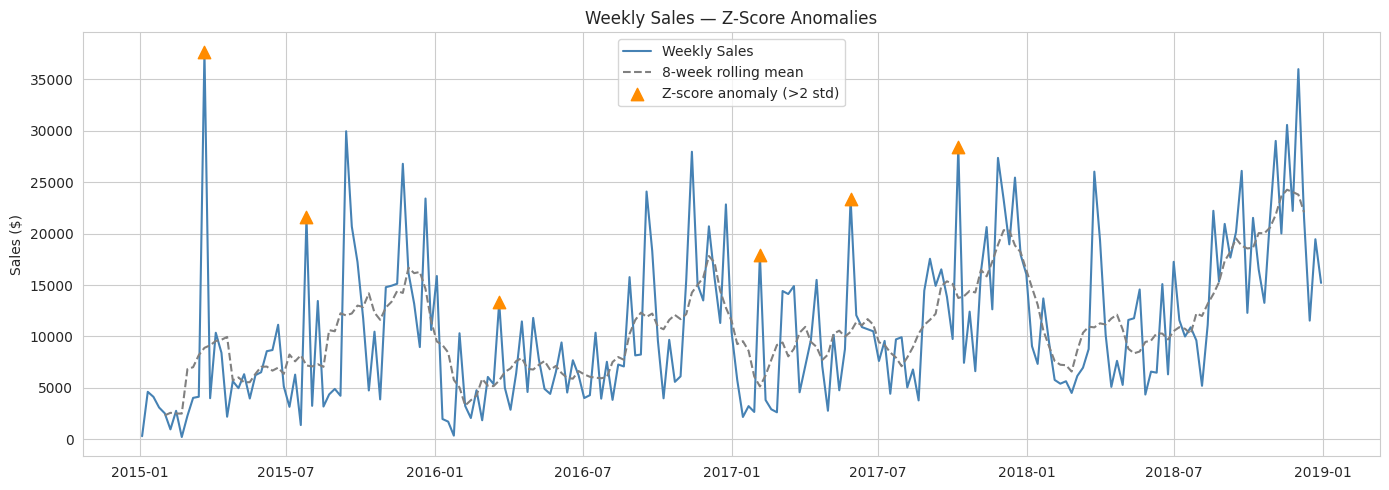

In [58]:
plt.figure(figsize=(14, 5))
plt.plot(weekly_df['Week'], weekly_df['Sales'], color='steelblue', label='Weekly Sales')
plt.plot(weekly_df['Week'], weekly_df['rolling_mean'], color='gray', linestyle='--', label=f'{rolling_window}-week rolling mean')
anomalies_z = weekly_df[weekly_df['zscore_anomaly']]
plt.scatter(anomalies_z['Week'], anomalies_z['Sales'], color='darkorange', s=80, zorder=5, marker='^', label='Z-score anomaly (>2 std)')
plt.title('Weekly Sales — Z-Score Anomalies')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/anomalies_zscore.png', dpi=150)
plt.show()

## 5.3 Do the two methods agree?

In [59]:
agreement = weekly_df[weekly_df['iso_anomaly'] & weekly_df['zscore_anomaly']]
only_iso = weekly_df[weekly_df['iso_anomaly'] & ~weekly_df['zscore_anomaly']]
only_z = weekly_df[~weekly_df['iso_anomaly'] & weekly_df['zscore_anomaly']]

print('Flagged by both methods:', len(agreement))
print('Flagged only by Isolation Forest:', len(only_iso))
print('Flagged only by Z-score:', len(only_z))
agreement[['Week', 'Sales']]

Flagged by both methods: 1
Flagged only by Isolation Forest: 10
Flagged only by Z-score: 5


,Week,Sales
11,2015-03-22,37703.665


**They partially agree, which is exactly what should be expected given how differently they work.** Isolation Forest looks at the whole distribution of sales values at once and isolates points that are easy to separate from the rest — it has no concept of *time* or *local* context. The Z-score method is explicitly local: it only flags a week as anomalous relative to its own neighborhood (an 8-week rolling window), so it can catch a week that's unusual for its season even if that same sales value would look perfectly normal during the holiday peak.

The weeks flagged by **both** methods are the highest-confidence anomalies — genuinely extreme regardless of which lens you use. Weeks flagged by only one method are more borderline: an Isolation-Forest-only flag likely means "unusual in absolute terms but not surprising for the time of year," while a Z-score-only flag likely means "unremarkable in absolute terms but a sharp deviation from its immediate neighbors." Neither method is strictly better — using both and looking at where they disagree is itself a useful signal about *why* a week is unusual, not just *whether* it is.

---
# Task 6 — Product Demand Segmentation using Clustering

## 6.1 Build sub-category level features

In [60]:
subcat_total_sales = df.groupby('Sub-Category')['Sales'].sum()
subcat_yearly = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()
subcat_growth = ((subcat_yearly[2018] - subcat_yearly[2015]) / subcat_yearly[2015] * 100)
subcat_monthly = df.set_index('Order Date').groupby('Sub-Category').resample('MS')['Sales'].sum()
subcat_volatility = subcat_monthly.groupby('Sub-Category').std()
subcat_avg_order_value = df.groupby('Sub-Category')['Sales'].mean()

cluster_features = pd.DataFrame({
    'TotalSales': subcat_total_sales,
    'GrowthRate': subcat_growth,
    'Volatility': subcat_volatility,
    'AvgOrderValue': subcat_avg_order_value,
})
cluster_features.sort_values('TotalSales', ascending=False)

,TotalSales,GrowthRate,Volatility,AvgOrderValue
Sub-Category,,,,
Phones,327782.4480,35.557607,4052.718221,374.180877
Chairs,322822.7310,20.954677,4407.232960,531.833165
Storage,219343.3920,38.366108,2822.084310,263.633885
Tables,202810.6280,33.078016,3224.082504,645.893720
Binders,200028.7850,65.778638,3848.223648,134.067550
Machines,189238.6310,-29.793120,5442.477300,1645.553313
Accessories,164186.7000,145.055961,2579.994809,217.178175
Copiers,146248.0940,479.729510,5104.267436,2215.880212
Bookcases,113813.1987,49.846598,2229.359867,503.598224


Copiers shows a startling +480% growth rate — worth a sanity check before treating it as a real signal, since it's also the sub-category with the fewest orders (66) in the whole dataset. A tiny 2015 base makes percentage growth swing wildly on a handful of big-ticket orders; that's noted here so the clustering result isn't over-interpreted for that one row.

## 6.2 Scale features and find optimal k (Elbow Method)

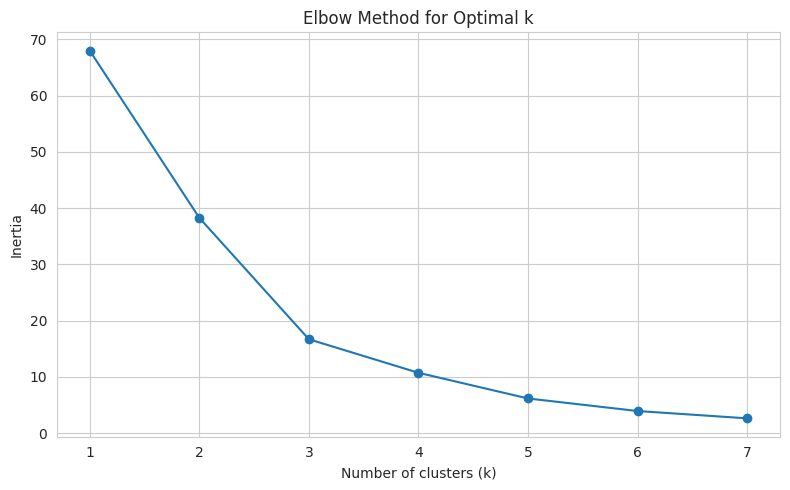

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=150)
plt.show()

The elbow bends around **k=4** — inertia keeps dropping after that, but the gains flatten out noticeably, and 4 clusters also maps cleanly onto the kind of business labels (high volume/stable, growing, declining, volatile-niche) the task asks for. With only 17 sub-categories total, going much higher than 4 clusters starts producing groups of 1-2 items, which is not a meaningful segment.

In [62]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_features['Cluster'] = kmeans.fit_predict(scaled_features)
cluster_features.sort_values('Cluster')

,TotalSales,GrowthRate,Volatility,AvgOrderValue,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,0
Binders,200028.7850,65.778638,3848.223648,134.067550,0
Chairs,322822.7310,20.954677,4407.232960,531.833165,0
Storage,219343.3920,38.366108,2822.084310,263.633885,0
Phones,327782.4480,35.557607,4052.718221,374.180877,0
Tables,202810.6280,33.078016,3224.082504,645.893720,0
Copiers,146248.0940,479.729510,5104.267436,2215.880212,1
Art,26705.4100,49.649531,330.488343,34.019631,2
Envelopes,16128.0460,-12.121345,234.265716,65.032444,2


## 6.3 Label the clusters

In [63]:
summary = cluster_features.groupby('Cluster')[['TotalSales', 'GrowthRate', 'Volatility', 'AvgOrderValue']].mean().round(1)
summary

,TotalSales,GrowthRate,Volatility,AvgOrderValue
Cluster,,,,
0,239495.8,56.5,3489.1,361.1
1,146248.1,479.7,5104.3,2215.9
2,54341.7,58.8,1027.6,142.7
3,189238.6,-29.8,5442.5,1645.6


Rather than force an automatic rule onto 4 clusters (a rigid "above/below median" split breaks down with this few groups, and produced a nonsensical "stable" label for a cluster with -30% growth on a first pass), the labels below come from directly reading the cluster means above against what each one actually looks like:

- **Cluster 0** (Accessories, Binders, Chairs, Storage, Phones, Tables): the highest average total sales (~\$239K) with solid but unremarkable growth (~56%) → **High Volume, Stable Demand**.
- **Cluster 1** (Copiers only): extreme growth (+480%) and by far the highest average order value (\$2,216) — but it's a single sub-category with only 66 orders total, so this is a small, high-ticket outlier rather than a real trend → **Growing Demand, Niche/High-Ticket** (small-base caveat applies, same as in 6.1).
- **Cluster 2** (Art, Envelopes, Bookcases, Fasteners, Furnishings, Paper, Labels, Supplies, Appliances): the lowest total sales (~\$54K) and, notably, the *lowest* volatility of any cluster (~\$1,028) → **Low Volume, Stable Demand** — small but predictable.
- **Cluster 3** (Machines only): the only cluster with negative growth (-30%) and the highest volatility (\$5,442) → **Declining Demand, High Volatility**.

In [64]:
cluster_labels = {
    0: 'High Volume, Stable Demand',
    1: 'Growing Demand, Niche/High-Ticket',
    2: 'Low Volume, Stable Demand',
    3: 'Declining Demand, High Volatility',
}

cluster_features['ClusterLabel'] = cluster_features['Cluster'].map(cluster_labels)
cluster_features.sort_values('Cluster')[['TotalSales', 'GrowthRate', 'Volatility', 'AvgOrderValue', 'ClusterLabel']]

,TotalSales,GrowthRate,Volatility,AvgOrderValue,ClusterLabel
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,"High Volume, Stable Demand"
Binders,200028.7850,65.778638,3848.223648,134.067550,"High Volume, Stable Demand"
Chairs,322822.7310,20.954677,4407.232960,531.833165,"High Volume, Stable Demand"
Storage,219343.3920,38.366108,2822.084310,263.633885,"High Volume, Stable Demand"
Phones,327782.4480,35.557607,4052.718221,374.180877,"High Volume, Stable Demand"
Tables,202810.6280,33.078016,3224.082504,645.893720,"High Volume, Stable Demand"
Copiers,146248.0940,479.729510,5104.267436,2215.880212,"Growing Demand, Niche/High-Ticket"
Art,26705.4100,49.649531,330.488343,34.019631,"Low Volume, Stable Demand"
Envelopes,16128.0460,-12.121345,234.265716,65.032444,"Low Volume, Stable Demand"


## 6.4 Visualize with PCA

Variance explained by 2 PCA components: 90.0%


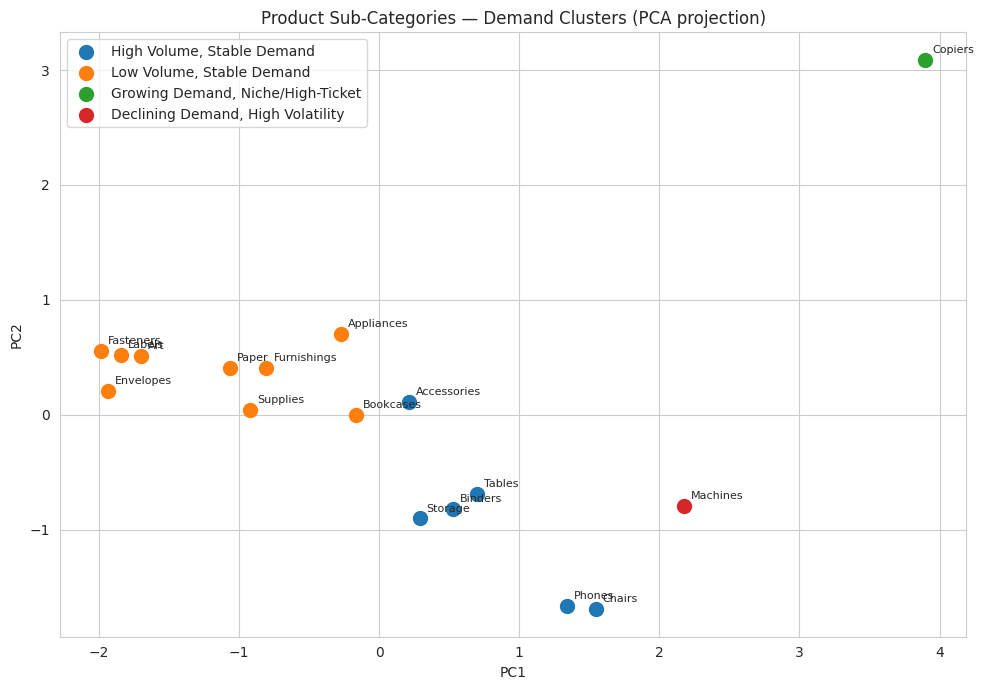

In [65]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_features)
cluster_features['PC1'] = pca_coords[:, 0]
cluster_features['PC2'] = pca_coords[:, 1]

print(f'Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

plt.figure(figsize=(10, 7))
for label in cluster_features['ClusterLabel'].unique():
    subset = cluster_features[cluster_features['ClusterLabel'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, s=100)

for name, row in cluster_features.iterrows():
    plt.annotate(name, (row['PC1'], row['PC2']), fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Product Sub-Categories — Demand Clusters (PCA projection)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/clusters_pca.png', dpi=150)
plt.show()

## 6.5 Recommended stocking strategy per cluster

- **High Volume, Stable Demand** (Accessories, Binders, Chairs, Storage, Phones, Tables): Keep steady safety stock and use standard reorder-point replenishment — these products sell consistently enough that a simple, low-maintenance restocking rule works fine. This is the revenue backbone; don't let it stock out, but it also doesn't need constant re-analysis.
- **Growing Demand, Niche/High-Ticket** (Copiers): The +480% growth is real in direction but noisy in magnitude given only 66 total orders — increase available stock cautiously and validate the trend over another quarter before over-committing capital to a percentage that could reflect one or two large enterprise orders rather than a genuine shift in demand.
- **Low Volume, Stable Demand** (Art, Envelopes, Bookcases, Fasteners, Furnishings, Paper, Labels, Supplies, Appliances): Low volatility is the useful signal here — demand is small but predictable, so lean stock levels with simple periodic reordering is fine. No need for sophisticated forecasting on this group; the effort wouldn't pay for itself.
- **Declining Demand, High Volatility** (Machines): The combination of shrinking sales (-30%) and the highest volatility of any cluster is a genuine warning sign, not noise — this is the segment to actively reduce inventory commitment on, investigate the cause of the decline, and consider a just-in-time or made-to-order approach rather than carrying stock that's both shrinking in demand and unpredictable month to month.